In [22]:
import serial
import numpy as np
import time
from matplotlib import pyplot as plt
from ribbn_scripts.hardware_api.hardware import Exciter,Tag
import json

In [23]:
com_port1="/dev/tty.usbmodem21201"
tag1=Tag(com_port1)
ip_port_out = tag1.get_ip_port()
print(ip_port_out)
if ip_port_out['net']=='up':
    tag1.connect_wifi(ip_port_out["ip"], ip_port_out["port"])
else:
    raise Exception("Net not connected.")
print(tag1.get_mac_wifi())

com_port2="/dev/tty.usbmodem213301"
tag2=Tag(com_port2)
ip_port_out = tag2.get_ip_port()
print(ip_port_out)
if ip_port_out['net']=='up':
    tag2.connect_wifi(ip_port_out["ip"], ip_port_out["port"])
else:
    raise Exception("Net not connected.")
print(tag2.get_mac_wifi())


{'net': 'up', 'ip': '192.168.1.24', 'port': 3333, 'rssi': -80}
98:A3:16:8F:58:E8
{'net': 'up', 'ip': '192.168.1.9', 'port': 3333, 'rssi': -75}
58:E6:C5:01:08:CC


In [24]:
tag1.listen_esync_wifi()
tag2.listen_esync_wifi()

b'esync:listening\r\n' 	 b'esync:listening\r\n'
b'esync:listening\r\n' 	 b'esync:listening\r\n'


In [25]:
tag1.queue_adc_read_wifi(300)
tag2.queue_mpp_wifi(1)

b'q:queued, adc_300\n' 	 b'q:queued, adc_300\n'
b'q:queued, mpp_1\n' 	 b'q:queued, mpp_1\n'


In [26]:
# print(tag2.read_queued_wifx/i(60))
print("----")
time.sleep(5)
print(tag2.read_queued_wifi(60))


----
{'info': 'mpp', 'ch': 8, 'passes': 1, 'ok': 1}


In [27]:
# print(tag1.read_queued_wifi(10))
print("----")
mpp_data=tag1.read_queued_wifi(10)


----


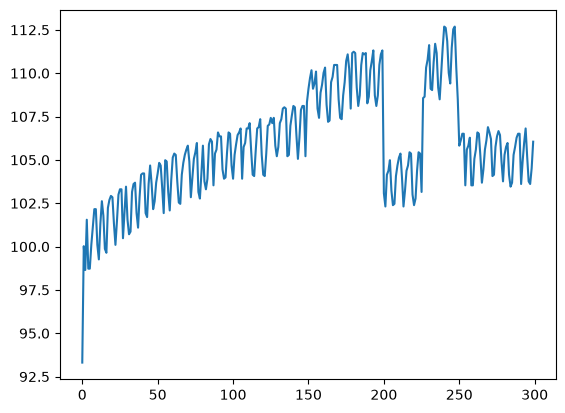

In [28]:
plt.plot(list(map(float, mpp_data['data'].split(','))))
plt.show()